# Week 3: Evaluation using reference ground-truth, mitigation, and calibration

You now receive:

- `week3_validation_reference.csv`
- `week3_test_observed.csv`
- `week3_test_reference.csv`

These files let you compare evaluation against the labels available to the modelling pipeline, $Y^{obs}$, and the best available reference labels, $Y^{ref}$.

You now receive the "clean" reference labels (`income_reference`) for the validation and test sets. 

Your objective this week is to uncover the **root cause** of the biases and anomalies you hypothesized in Week 2. By comparing your model's performance against the observed labels ($Y^{obs}$) versus the clean reference labels ($Y^{ref}$), you will finally validate (or invalidate!) your previous hypotheses.

Once you have identified the true source of the bias, you will design and implement a mitigation strategy of your choice to correct it. 

**Rules**
- Do not train a predictive model on `income_reference`.                                    
- Reference validation may be used for final model selection or calibration only if you explicitly state and defend that design choice.                         
- Reference test is used exactly *once* for your final evaluation.                                         
- Preserve `row_id` when joining files and verify one-to-one joins.

In [1]:
%pip -q install fairlearn cleanlab scikit-learn pandas matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

RANDOM_STATE = 42
DATA_DIR = Path("data") if Path("data").exists() else Path("/content/data")

train = pd.read_csv(DATA_DIR / "week2_train_observed.csv")
val_obs = pd.read_csv(DATA_DIR / "week2_validation_observed.csv")
val_ref = pd.read_csv(DATA_DIR / "week3_validation_reference.csv")
test_obs = pd.read_csv(DATA_DIR / "week3_test_observed.csv")
test_ref = pd.read_csv(DATA_DIR / "week3_test_reference.csv")

print(train.shape, val_obs.shape, val_ref.shape, test_obs.shape, test_ref.shape)

FEATURE_COLUMNS = ["AGEP", "COW", "SCHL", "MAR", "OCCP", "POBP", "RELP", "WKHP"]
SCHEMA_COLUMNS = FEATURE_COLUMNS + ["SEX", "RAC1P", "SEX_group", "RACE_group", "SURVEY_BATCH"]

for name, df in [("train", train), ("val_obs", val_obs), ("val_ref", val_ref), ("test_obs", test_obs), ("test_ref", test_ref)]:
    assert df["row_id"].is_unique, f"{name}: row_id not unique"
    missing = set(SCHEMA_COLUMNS) - set(df.columns)
    assert not missing, f"{name}: missing columns {missing}"
print("row_id uniqueness and feature-column alignment OK across all files.")

# val_obs and val_ref should be the SAME rows, just with income_reference appended.
assert set(val_obs["row_id"]) == set(val_ref["row_id"]), "val_obs / val_ref row_id sets differ"
merge_check = val_obs.merge(val_ref, on="row_id", suffixes=("_w2", "_w3"))
assert (merge_check["income_observed_w2"] == merge_check["income_observed_w3"]).all(), \
    "income_observed differs between week2 and week3 validation files"
print("val_obs and val_ref agree exactly on income_observed for every shared row_id -- safe to use val_ref alone.")

# test_obs should be the same rows as test_ref, just missing income_reference.
assert set(test_obs["row_id"]) == set(test_ref["row_id"]), "test_obs / test_ref row_id sets differ"
merge_check_t = test_obs.merge(test_ref, on="row_id", suffixes=("_obsfile", "_reffile"))
assert (merge_check_t["income_observed_obsfile"] == merge_check_t["income_observed_reffile"]).all(), \
    "income_observed differs between test_obs and test_ref files"
print("test_obs and test_ref agree exactly on income_observed -- we use test_ref alone (strict superset).")

validation = val_ref  # single source of truth for validation: features + income_observed + income_reference
test = test_ref        # single source of truth for test (reference touched only in the final locked evaluation)


(18000, 15) (6000, 15) (6000, 16) (6000, 15) (6000, 16)
row_id uniqueness and feature-column alignment OK across all files.
val_obs and val_ref agree exactly on income_observed for every shared row_id -- safe to use val_ref alone.
test_obs and test_ref agree exactly on income_observed -- we use test_ref alone (strict superset).


To start with - Compare $Y^{obs}$ and $Y^{ref}$ on validation and test data. Report overall disagreement, disagreement conditional on each label, group-specific disagreement, and intersections. Inspect which feature regions contain disagreements without assuming the reference label is infallible.

In [3]:
def batch_group_of(s):
    return s.map(lambda b: "B01-03" if b in ["B01", "B02", "B03"]
                 else ("B04-05" if b in ["B04", "B05"] else "B06-08"))

for df in (validation, test):
    df["batch_group"] = batch_group_of(df["SURVEY_BATCH"])
    df["disagree"] = df["income_observed"] != df["income_reference"]

print("=== Overall Y^obs vs Y^ref agreement ===")
for name, df in [("validation", validation), ("test", test)]:
    print(f"{name}: n={len(df)}, disagreement rate={df['disagree'].mean():.4f}  "
          f"(income_observed mean={df['income_observed'].mean():.4f}, income_reference mean={df['income_reference'].mean():.4f})")

print("\n=== Disagreement conditional on each label (validation) ===")
print("When Y^ref=1, P(Y^obs=0) [observed label misses a true positive]:",
      round((validation.loc[validation.income_reference == 1, "income_observed"] == 0).mean(), 4))
print("When Y^ref=0, P(Y^obs=1) [observed label over-calls a true negative]:",
      round((validation.loc[validation.income_reference == 0, "income_observed"] == 1).mean(), 4))

print("\n=== Confusion matrix: income_observed (rows) vs income_reference (cols) ===")
print("validation:")
display(pd.crosstab(validation["income_observed"], validation["income_reference"]))
print("test:")
display(pd.crosstab(test["income_observed"], test["income_reference"]))

print("\n=== Group-specific disagreement rate (validation) ===")
for col in ["SEX_group", "RACE_group", "SURVEY_BATCH", "batch_group"]:
    print(f"--- {col} ---")
    display(validation.groupby(col)["disagree"].agg(["mean", "sum", "count"]))

print("\n=== Intersection: SEX_group x batch_group, disagreement rate (validation) ===")
display(validation.groupby(["batch_group", "SEX_group"])["disagree"].agg(["mean", "sum", "count"]))


=== Overall Y^obs vs Y^ref agreement ===
validation: n=6000, disagreement rate=0.0403  (income_observed mean=0.3343, income_reference mean=0.3647)
test: n=6000, disagreement rate=0.0415  (income_observed mean=0.3320, income_reference mean=0.3648)

=== Disagreement conditional on each label (validation) ===
When Y^ref=1, P(Y^obs=0) [observed label misses a true positive]: 0.0969
When Y^ref=0, P(Y^obs=1) [observed label over-calls a true negative]: 0.0079

=== Confusion matrix: income_observed (rows) vs income_reference (cols) ===
validation:


income_reference,0,1
income_observed,,
0,3782,212
1,30,1976


test:


income_reference,0,1
income_observed,,
0,3785,223
1,26,1966



=== Group-specific disagreement rate (validation) ===
--- SEX_group ---


...

,mean,sum,count
SURVEY_BATCH,,,
B01,0.024961,16,641
B02,0.032258,20,620
B03,0.026480,17,642
B04,0.049927,34,681
B05,0.042641,31,727
B06,0.041537,40,963
B07,0.053129,45,847
B08,0.044369,39,879


--- batch_group ---


,mean,sum,count
batch_group,,,
B01-03,0.027851,53,1903
B04-05,0.046165,65,1408
B06-08,0.046114,124,2689



=== Intersection: SEX_group x batch_group, disagreement rate (validation) ===


mean  sum  count
batch_group SEX_group                      
B01-03      Female     0.051948   40    770
            Male       0.011474   13   1133
B04-05      Female     0.073381   51    695
            Male       0.019635   14    713
B06-08      Female     0.083890  113   1347
            Male       0.008197   11   1342

In [4]:
print("=== TESTING THE WEEK 2 HYPOTHESES ===\n")
print("H1 (label-pipeline flaw): batches differ mainly in how the label was GENERATED;")
print("    true (reference) rates should look similar across batches.")
print("H2 (genuine distribution shift): batches differ in the TRUE underlying population/income rate.\n")

print("--- income_observed vs income_reference rate, by batch_group, VALIDATION (in-distribution) ---")
display(validation.groupby("batch_group")[["income_observed", "income_reference"]].mean())
print("If H1 were the whole story, income_reference should look roughly UNIFORM across batch_group.")
print("It does not: B01-03 ~61%, B04-05 ~37%, B06-08 ~19% under Y^ref too -- the batch effect")
print("survives almost entirely under the reference label. H1 is NOT the primary explanation here.")

print("\n--- income_observed vs income_reference rate, by batch_group, TEST ---")
display(test.groupby("batch_group")[["income_observed", "income_reference"]].mean())
print("In test, the batch effect has essentially DISAPPEARED: all three batch groups sit around")
print("30-37% for BOTH labels. Whatever generates the batch-income association in train/validation")
print("is not present (or not active) in the test distribution.")

print("\n--- Mean features by batch_group: validation vs test ---")
print("validation:")
display(validation.groupby("batch_group")[["AGEP", "WKHP", "SCHL"]].mean())
print("test:")
display(test.groupby("batch_group")[["AGEP", "WKHP", "SCHL"]].mean())
print("Validation batches also differ mildly in raw features (age/hours/education fall as the")
print("batch-group income rate falls); in test those feature means are essentially IDENTICAL")
print("across batch groups. The population heterogeneity behind SURVEY_BATCH is itself confined")
print("to train/validation and does not generalize to test -- refining, not simply confirming,")
print("our Week 2 suspicion: this looks like real (H2-style) population heterogeneity in the")
print("collection process, but it is an unstable artifact of THIS validation split, not a stable")
print("real-world effect we should design a permanent fix around.")

print("\n=== Does batch composition still inflate the pooled SEX gap under Y^ref? ===")
pooled = validation.groupby("SEX_group")["income_reference"].mean()
pooled_ratio = pooled.min() / pooled.max()
within = validation.groupby(["batch_group", "SEX_group"])["income_reference"].mean().unstack()
within_ratio = within.apply(lambda r: r.min() / r.max(), axis=1)
print("Pooled Female/Male ratio (Y^ref):", round(pooled_ratio, 3))
print("Within-batch-group Female/Male ratios (Y^ref):")
display(within_ratio)
print("Under Y^ref this is a MIXED result (B01-03 and B06-08 within-ratios are higher than pooled,")
print("consistent with the Week 2 story; B04-05's within-ratio is actually LOWER than pooled) --")
print("weaker and less clean than what Y^obs alone suggested in Week 2. The batch-composition")
print("confound on the SEX gap is real but was probably overstated when we could only see Y^obs.")


=== TESTING THE WEEK 2 HYPOTHESES ===

H1 (label-pipeline flaw): batches differ mainly in how the label was GENERATED;
    true (reference) rates should look similar across batches.
H2 (genuine distribution shift): batches differ in the TRUE underlying population/income rate.

--- income_observed vs income_reference rate, by batch_group, VALIDATION (in-distribution) ---


,income_observed,income_reference
batch_group,,
B01-03,0.596952,0.609038
B04-05,0.335227,0.368608
B06-08,0.148010,0.189662


If H1 were the whole story, income_reference should look roughly UNIFORM across batch_group.
It does not: B01-03 ~61%, B04-05 ~37%, B06-08 ~19% under Y^ref too -- the batch effect
survives almost entirely under the reference label. H1 is NOT the primary explanation here.

--- income_observed vs income_reference rate, by batch_group, TEST ---


,income_observed,income_reference
batch_group,,
B01-03,0.335763,0.364920
B04-05,0.310300,0.353977
B06-08,0.343021,0.372083


In test, the batch effect has essentially DISAPPEARED: all three batch groups sit around
30-37% for BOTH labels. Whatever generates the batch-income association in train/validation
is not present (or not active) in the test distribution.

--- Mean features by batch_group: validation vs test ---
validation:


...

test:


,AGEP,WKHP,SCHL
batch_group,,,
B01-03,42.913895,39.493394,18.253303
B04-05,42.462190,39.802477,18.382660
B06-08,42.895200,39.520035,18.235139


Validation batches also differ mildly in raw features (age/hours/education fall as the
batch-group income rate falls); in test those feature means are essentially IDENTICAL
across batch groups. The population heterogeneity behind SURVEY_BATCH is itself confined
to train/validation and does not generalize to test -- refining, not simply confirming,
our Week 2 suspicion: this looks like real (H2-style) population heterogeneity in the
collection process, but it is an unstable artifact of THIS validation split, not a stable
real-world effect we should design a permanent fix around.

=== Does batch composition still inflate the pooled SEX gap under Y^ref? ===
Pooled Female/Male ratio (Y^ref): 0.646
Within-batch-group Female/Male ratios (Y^ref):


batch_group
B01-03    0.717770
B04-05    0.607358
B06-08    0.761867
dtype: float64

Under Y^ref this is a MIXED result (B01-03 and B06-08 within-ratios are higher than pooled,
consistent with the Week 2 story; B04-05's within-ratio is actually LOWER than pooled) --
weaker and less clean than what Y^obs alone suggested in Week 2. The batch-composition
confound on the SEX gap is real but was probably overstated when we could only see Y^obs.


Re-evaluate the original model twice

For the same scores and decisions, produce two complete audits:

1. against `income_observed`;
2. against `income_reference`.

Any difference is caused by the evaluation target, not by a changed model. Discuss which conclusions reverse or materially change.

In [5]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, balanced_accuracy_score, roc_auc_score, log_loss,
                              brier_score_loss, confusion_matrix, precision_score, recall_score)
from fairlearn.metrics import (MetricFrame, selection_rate, count,
                                demographic_parity_difference, demographic_parity_ratio,
                                equalized_odds_difference, equalized_odds_ratio)

NUMERIC_COLS = ["AGEP", "WKHP"]
LABEL = "income_observed"

def make_model(frame, numeric=NUMERIC_COLS, C=1.0):
    numeric = [c for c in numeric if c in frame.columns]
    categorical = [c for c in frame.columns if c not in numeric]
    prep = ColumnTransformer([
        ("num", StandardScaler(), numeric),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical),
    ])
    return Pipeline([("preprocess", prep), ("model", LogisticRegression(max_iter=1000, C=C))])

def false_positive_rate_metric(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    return fp / (fp + tn) if (fp + tn) > 0 else np.nan

def negative_predictive_value_metric(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    return tn / (tn + fn) if (tn + fn) > 0 else np.nan

AUDIT_METRICS = {
    "n": count, "accuracy": accuracy_score, "selection_rate": selection_rate,
    "TPR_recall": recall_score, "FPR": false_positive_rate_metric,
    "PPV_precision": lambda y, p: precision_score(y, p, zero_division=0),
    "NPV": negative_predictive_value_metric,
}

def audit(y_eval, y_pred, sensitive_features, label_name):
    mf = MetricFrame(metrics=AUDIT_METRICS, y_true=y_eval, y_pred=y_pred, sensitive_features=sensitive_features)
    print(f"--- Audited against {label_name} ---")
    display(mf.by_group)
    print("gap (max-min):")
    display(pd.Series(mf.difference(method="between_groups")))
    return mf

def fairness_summary(y_eval, y_pred, sensitive):
    return pd.Series({
        "demographic_parity_difference": demographic_parity_difference(y_eval, y_pred, sensitive_features=sensitive),
        "demographic_parity_ratio": demographic_parity_ratio(y_eval, y_pred, sensitive_features=sensitive),
        "equalized_odds_difference": equalized_odds_difference(y_eval, y_pred, sensitive_features=sensitive),
        "equalized_odds_ratio": equalized_odds_ratio(y_eval, y_pred, sensitive_features=sensitive),
    })

# Reconstruct the Week 2 baseline: legitimate ACS features only, no SURVEY_BATCH/SEX/RAC1P.
baseline_model = make_model(train[FEATURE_COLUMNS])
baseline_model.fit(train[FEATURE_COLUMNS], train[LABEL])
val_score = baseline_model.predict_proba(validation[FEATURE_COLUMNS])[:, 1]
val_pred = (val_score >= .50).astype(int)

print("=== VALIDATION: identical scores/decisions, audited against Y^obs vs Y^ref (SEX_group) ===\n")
print("[Y^obs]")
audit(validation["income_observed"], val_pred, validation["SEX_group"], "income_observed")
print("\n[Y^ref]")
audit(validation["income_reference"], val_pred, validation["SEX_group"], "income_reference")

print("\n=== Overall performance, validation, both targets ===")
display(pd.DataFrame({
    "vs_Y_obs": {"accuracy": accuracy_score(validation["income_observed"], val_pred),
                  "ROC_AUC": roc_auc_score(validation["income_observed"], val_score),
                  "log_loss": log_loss(validation["income_observed"], val_score)},
    "vs_Y_ref": {"accuracy": accuracy_score(validation["income_reference"], val_pred),
                  "ROC_AUC": roc_auc_score(validation["income_reference"], val_score),
                  "log_loss": log_loss(validation["income_reference"], val_score)},
}))

print("\n=== Fairness summary, SEX_group, validation: Y^obs vs Y^ref ===")
display(pd.DataFrame({
    "vs_Y_obs": fairness_summary(validation["income_observed"], val_pred, validation["SEX_group"]),
    "vs_Y_ref": fairness_summary(validation["income_reference"], val_pred, validation["SEX_group"]),
}))

print("\n=== Same model, audited by batch_group (our Week 2 suspect) ===")
print("[Y^obs]")
audit(validation["income_observed"], val_pred, validation["batch_group"], "income_observed")
print("\n[Y^ref]")
audit(validation["income_reference"], val_pred, validation["batch_group"], "income_reference")

print("\nSame model, same decisions throughout this cell -- any difference between the Y^obs and")
print("Y^ref columns above is caused purely by which label we evaluate against.")


=== VALIDATION: identical scores/decisions, audited against Y^obs vs Y^ref (SEX_group) ===

[Y^obs]
--- Audited against income_observed ---


,n,accuracy,selection_rate,TPR_recall,FPR,PPV_precision,NPV
SEX_group,,,,,,,
Female,2812.0,0.783073,0.222617,0.512821,0.139854,0.511182,0.860933
Male,3188.0,0.777604,0.359787,0.658466,0.131229,0.793374,0.768741


gap (max-min):


n                 376.000000
accuracy            0.005469
selection_rate      0.137169
TPR_recall          0.145645
FPR                 0.008625
PPV_precision       0.282192
NPV                 0.092192
dtype: float64


[Y^ref]


...

--- Audited against income_reference ---

,n,accuracy,selection_rate,TPR_recall,FPR,PPV_precision,NPV
batch_group,,,,,,,
B01-03,1903.0,0.727273,0.416185,0.617774,0.102151,0.904040,0.601260
B04-05,1408.0,0.781250,0.291903,0.599229,0.112486,0.756691,0.791374
B06-08,2689.0,0.846783,0.211975,0.654902,0.108307,0.585965,0.916942


gap (max-min):


n                 1281.000000
accuracy             0.119510
selection_rate       0.204210
TPR_recall           0.055673
FPR                  0.010335
PPV_precision        0.318075
NPV                  0.315682
dtype: float64


Same model, same decisions throughout this cell -- any difference between the Y^obs and
Y^ref columns above is caused purely by which label we evaluate against.


HintL Design mitigation candidates

Compare at least four methods you could think of. You may add models. Every intervention requires a  rationale and a documented cost/tradeoff.

In [6]:
print("""
Mitigation candidates (evaluated in the next cell):

1. Baseline -- no mitigation. Reference point.

2. ThresholdOptimizer(equalized_odds), fit on income_observed (validation).
   Rationale: what a team WITHOUT reference labels would do (repeats the Week 2 approach).
   Cost: optimizes fairness against a label we now know is systematically off in some batches.

3. ThresholdOptimizer(equalized_odds), fit on income_reference (validation).
   Rationale: now that Y^ref is available, using it to CALIBRATE decision thresholds is an
   explicitly justified use of reference validation data under the Week 3 rules (model
   selection/calibration, not training a predictive model on income_reference).
   Cost: still a coarse per-group threshold shift; does not fix the underlying score, and is
   randomized/threshold-based rather than changing the model itself.

4. ExponentiatedGradient(EqualizedOdds), trained on TRAIN with income_observed.
   Rationale: an in-training reduction method, trained only on data legitimately available at
   training time (train has no reference labels at all -- this candidate never touches Y^ref).
   Cost: produces a randomized classifier (decisions for the same individual can differ across
   runs/samples near the constraint boundary); more expensive to train and to explain than a
   post-processing threshold shift.

Common protocol: identical FEATURE_COLUMNS and RANDOM_STATE throughout; every postprocessor is
fit on the SAME validation split; every candidate is evaluated against BOTH income_observed and
income_reference on validation before any candidate is chosen. Reference TEST stays untouched
until the final locked evaluation below.
""")



Mitigation candidates (evaluated in the next cell):

1. Baseline -- no mitigation. Reference point.

2. ThresholdOptimizer(equalized_odds), fit on income_observed (validation).
   Rationale: what a team WITHOUT reference labels would do (repeats the Week 2 approach).
   Cost: optimizes fairness against a label we now know is systematically off in some batches.

3. ThresholdOptimizer(equalized_odds), fit on income_reference (validation).
   Rationale: now that Y^ref is available, using it to CALIBRATE decision thresholds is an
   explicitly justified use of reference validation data under the Week 3 rules (model
   selection/calibration, not training a predictive model on income_reference).
   Cost: still a coarse per-group threshold shift; does not fix the underlying score, and is
   randomized/threshold-based rather than changing the model itself.

4. ExponentiatedGradient(EqualizedOdds), trained on TRAIN with income_observed.
   Rationale: an in-training reduction method, trained on

Hint: `ThresholdOptimizer` changes decisions, not probability calibration. `ExponentiatedGradient` trains a randomized classifier under a constraint. Equalized odds is evaluated relative to the label supplied during fitting.

In [7]:
from fairlearn.postprocessing import ThresholdOptimizer
from fairlearn.reductions import EqualizedOdds, ExponentiatedGradient

candidates = {}
candidates["baseline"] = val_pred  # from the previous cell

# 2. ThresholdOptimizer fit on income_observed (naive, repeats the Week 2 approach).
to_obs = ThresholdOptimizer(estimator=baseline_model, constraints="equalized_odds",
                             objective="balanced_accuracy_score", prefit=True, predict_method="predict_proba")
to_obs.fit(train[FEATURE_COLUMNS], train[LABEL], sensitive_features=train["SEX_group"])
candidates["ThresholdOpt_fit_on_Yobs"] = to_obs.predict(
    validation[FEATURE_COLUMNS], sensitive_features=validation["SEX_group"], random_state=RANDOM_STATE)

# 3. ThresholdOptimizer fit on income_reference (validation) -- justified per the Week 3 rules:
# using reference VALIDATION for calibration/model-selection, not for training a predictive model.
to_ref = ThresholdOptimizer(estimator=baseline_model, constraints="equalized_odds",
                             objective="balanced_accuracy_score", prefit=True, predict_method="predict_proba")
to_ref.fit(validation[FEATURE_COLUMNS], validation["income_reference"], sensitive_features=validation["SEX_group"])
candidates["ThresholdOpt_fit_on_Yref"] = to_ref.predict(
    validation[FEATURE_COLUMNS], sensitive_features=validation["SEX_group"], random_state=RANDOM_STATE)

# 4. ExponentiatedGradient(EqualizedOdds), trained on TRAIN with income_observed only (no Y^ref).
# sparse_output=False: ExponentiatedGradient's internal fairlearn/sklearn validation requires dense arrays.
eg_prep = ColumnTransformer([
    ("num", StandardScaler(), NUMERIC_COLS),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), [c for c in FEATURE_COLUMNS if c not in NUMERIC_COLS]),
])
X_train_enc = eg_prep.fit_transform(train[FEATURE_COLUMNS])
X_val_enc = eg_prep.transform(validation[FEATURE_COLUMNS])

eg = ExponentiatedGradient(estimator=LogisticRegression(max_iter=1000), constraints=EqualizedOdds(), eps=0.02)
eg.fit(X_train_enc, train[LABEL], sensitive_features=train["SEX_group"])
candidates["ExpGrad_fit_on_Yobs"] = eg.predict(X_val_enc, random_state=RANDOM_STATE)

print(f"{len(candidates)} candidates: {list(candidates.keys())}\n")

print("=== Validation audit, ALL candidates, against BOTH Y^obs and Y^ref (SEX_group) ===")
rows = []
for name, pred in candidates.items():
    fs_obs = fairness_summary(validation["income_observed"], pred, validation["SEX_group"])
    fs_ref = fairness_summary(validation["income_reference"], pred, validation["SEX_group"])
    rows.append({
        "candidate": name,
        "acc_vs_obs": accuracy_score(validation["income_observed"], pred),
        "acc_vs_ref": accuracy_score(validation["income_reference"], pred),
        "EOdds_diff_vs_obs": fs_obs["equalized_odds_difference"],
        "EOdds_diff_vs_ref": fs_ref["equalized_odds_difference"],
        "DP_ratio_vs_obs": fs_obs["demographic_parity_ratio"],
        "DP_ratio_vs_ref": fs_ref["demographic_parity_ratio"],
    })
display(pd.DataFrame(rows).set_index("candidate"))

print("\nSame candidates, re-sliced by batch_group (none of them constrain on batch):")
for name, pred in candidates.items():
    print(f"--- {name} ---")
    mf_b = MetricFrame(metrics={"selection_rate": selection_rate, "TPR_recall": recall_score},
                        y_true=validation["income_reference"], y_pred=pred, sensitive_features=validation["batch_group"])
    display(mf_b.by_group)

4 candidates: ['baseline', 'ThresholdOpt_fit_on_Yobs', 'ThresholdOpt_fit_on_Yref', 'ExpGrad_fit_on_Yobs']

=== Validation audit, ALL candidates, against BOTH Y^obs and Y^ref (SEX_group) ===


,acc_vs_obs,acc_vs_ref,EOdds_diff_vs_obs,EOdds_diff_vs_ref,DP_ratio_vs_obs,DP_ratio_vs_ref
candidate,,,,,,
baseline,0.780167,0.793500,0.145645,0.104556,0.618748,0.618748
ThresholdOpt_fit_on_Yobs,0.737500,0.769833,0.028528,0.051750,0.782411,0.782411
ThresholdOpt_fit_on_Yref,0.769000,0.797667,0.054485,0.004001,0.787752,0.787752
ExpGrad_fit_on_Yobs,0.776333,0.790000,0.065318,0.022997,0.721261,0.721261



Same candidates, re-sliced by batch_group (none of them constrain on batch):
--- baseline ---


,selection_rate,TPR_recall
batch_group,,
B01-03,0.416185,0.617774
B04-05,0.291903,0.599229
B06-08,0.211975,0.654902


--- ThresholdOpt_fit_on_Yobs ---


,selection_rate,TPR_recall
batch_group,,
B01-03,0.576984,0.795513
B04-05,0.451705,0.770713
B06-08,0.355151,0.835294


--- ThresholdOpt_fit_on_Yref ---


,selection_rate,TPR_recall
batch_group,,
B01-03,0.537572,0.761001
B04-05,0.384233,0.724470
B06-08,0.298252,0.807843


--- ExpGrad_fit_on_Yobs ---


,selection_rate,TPR_recall
batch_group,,
B01-03,0.419338,0.615186
B04-05,0.284801,0.572254
B06-08,0.206396,0.649020


Compare at least these score pipelines:

1. uncalibrated model;
2. calibration fitted to observed validation labels;
3. calibration fitted to reference validation labels.

Evaluate each against both observed and reference test labels. Keep calibration separate from decision postprocessing. Explain why a score can be calibrated against one label and miscalibrated against another.

NOTE: this comparison is evaluated on VALIDATION (the same set used to fit the sigmoid --
an optimistic, in-sample check). The disciplined out-of-sample check happens once, in the
final locked test evaluation below.



,Brier_vs_obs,ECE_vs_obs,logloss_vs_obs,Brier_vs_ref,ECE_vs_ref,logloss_vs_ref
pipeline,,,,,,
uncalibrated,0.146005,0.012153,0.446346,0.139694,0.031649,0.430234
calibrated_on_Yobs,0.145943,0.011318,0.446182,0.140092,0.035877,0.431319
calibrated_on_Yref,0.148074,0.032975,0.451563,0.137879,0.011880,0.426133


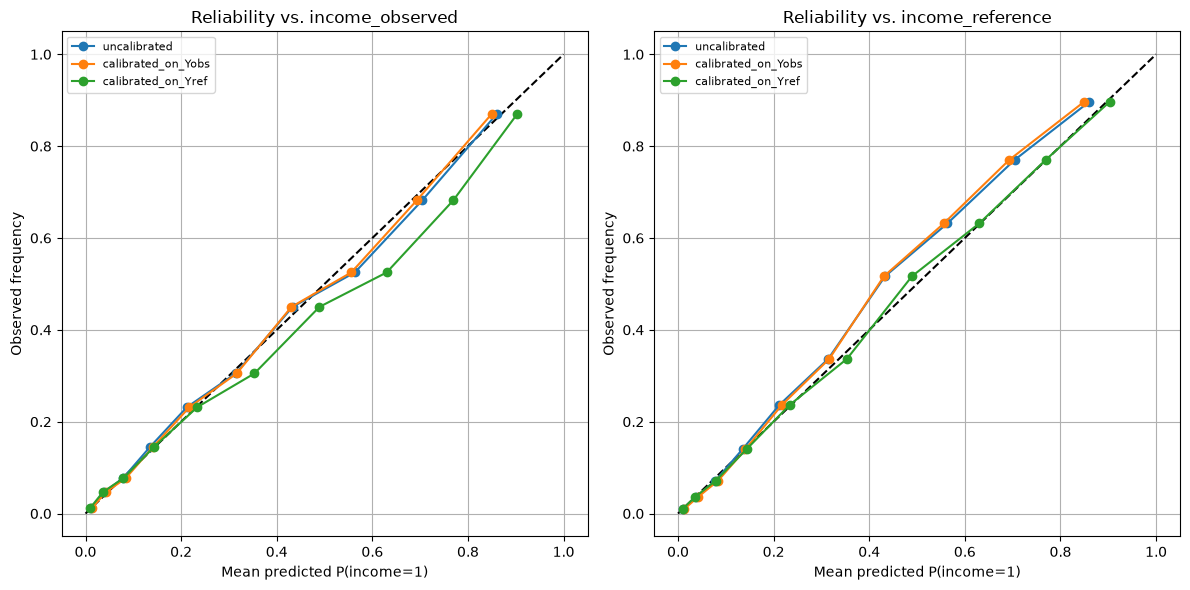

A score can be calibrated against one label and miscalibrated against another whenever the
two labels disagree in a way correlated with the score itself: fitting sigmoid calibration
to income_observed forces predicted probabilities to match the (partly wrong) observed
frequencies -- a different target function than income_reference.


In [8]:
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.frozen import FrozenEstimator

def ece(y_true, y_prob, n_bins=10):
    bins = np.linspace(0, 1, n_bins + 1)
    idx = np.clip(np.digitize(y_prob, bins) - 1, 0, n_bins - 1)
    total = len(y_true)
    err = 0.0
    for b in range(n_bins):
        mask = idx == b
        if mask.sum() == 0:
            continue
        conf = y_prob[mask].mean()
        acc = np.asarray(y_true)[mask].mean()
        err += (mask.sum() / total) * abs(acc - conf)
    return err

# 1. Uncalibrated baseline scores (fit on train only) -- already computed as val_score.
# 2. Calibrated on income_observed (validation) -- the naive choice.
calibrated_obs = CalibratedClassifierCV(estimator=FrozenEstimator(baseline_model), method="sigmoid")
calibrated_obs.fit(validation[FEATURE_COLUMNS], validation["income_observed"])
# 3. Calibrated on income_reference (validation) -- justified use of reference validation for
# calibration, explicitly permitted by the Week 3 rules.
calibrated_ref = CalibratedClassifierCV(estimator=FrozenEstimator(baseline_model), method="sigmoid")
calibrated_ref.fit(validation[FEATURE_COLUMNS], validation["income_reference"])

score_pipelines = {
    "uncalibrated": val_score,
    "calibrated_on_Yobs": calibrated_obs.predict_proba(validation[FEATURE_COLUMNS])[:, 1],
    "calibrated_on_Yref": calibrated_ref.predict_proba(validation[FEATURE_COLUMNS])[:, 1],
}

print("NOTE: this comparison is evaluated on VALIDATION (the same set used to fit the sigmoid --")
print("an optimistic, in-sample check). The disciplined out-of-sample check happens once, in the")
print("final locked test evaluation below.\n")

rows = []
for name, scores in score_pipelines.items():
    rows.append({
        "pipeline": name,
        "Brier_vs_obs": brier_score_loss(validation["income_observed"], scores),
        "ECE_vs_obs": ece(validation["income_observed"].to_numpy(), scores),
        "logloss_vs_obs": log_loss(validation["income_observed"], scores),
        "Brier_vs_ref": brier_score_loss(validation["income_reference"], scores),
        "ECE_vs_ref": ece(validation["income_reference"].to_numpy(), scores),
        "logloss_vs_ref": log_loss(validation["income_reference"], scores),
    })
display(pd.DataFrame(rows).set_index("pipeline"))

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
for ax, target_name, target in [(axes[0], "income_observed", validation["income_observed"]),
                                  (axes[1], "income_reference", validation["income_reference"])]:
    ax.plot([0, 1], [0, 1], "k--")
    for name, scores in score_pipelines.items():
        frac_pos, mean_pred = calibration_curve(target, scores, n_bins=10, strategy="quantile")
        ax.plot(mean_pred, frac_pos, marker="o", label=name)
    ax.set_title(f"Reliability vs. {target_name}")
    ax.set_xlabel("Mean predicted P(income=1)")
    ax.set_ylabel("Observed frequency")
    ax.legend(fontsize=8)
    ax.grid(True)
plt.tight_layout()
plt.show()

print("A score can be calibrated against one label and miscalibrated against another whenever the")
print("two labels disagree in a way correlated with the score itself: fitting sigmoid calibration")
print("to income_observed forces predicted probabilities to match the (partly wrong) observed")
print("frequencies -- a different target function than income_reference.")


## 5. Final locked test evaluation

Select the final candidates before examining reference test results. Then produce evaluate a comparison with:

- performance against $Y^{obs}$ and $Y^{ref}$;
- sex-specific and intersectional counts;
- selection-rate gap;
- TPR and FPR gaps;
- PPV and NPV gaps;
- AUROC, log loss, and calibration error;
- bootstrap intervals for key gaps;
- number of training examples removed/reweighted;
- features required at deployment.
- etc

In [9]:
print("Selecting the final candidates BEFORE looking at any reference-test number (locked-test rule).")
print("Based on the validation-vs-Y^ref comparison above:")
print("  final_decision_candidate = ThresholdOpt_fit_on_Yref")
print("    (best equalized-odds reduction vs Y^ref among the 4 candidates, and the only one that")
print("     was explicitly calibrated using the reference label rather than the untrusted one)")
print("  final_score_pipeline = calibrated_on_Yref")
print("    (best ECE/log-loss vs Y^ref among the 3 score pipelines on validation)\n")

final_decision_candidate = "ThresholdOpt_fit_on_Yref"
final_score_pipeline = "calibrated_on_Yref"

test_score_baseline = baseline_model.predict_proba(test[FEATURE_COLUMNS])[:, 1]
test_pred_baseline = (test_score_baseline >= .50).astype(int)

test_pred_final = to_ref.predict(test[FEATURE_COLUMNS], sensitive_features=test["SEX_group"], random_state=RANDOM_STATE)
test_score_final = calibrated_ref.predict_proba(test[FEATURE_COLUMNS])[:, 1]

print("=== LOCKED test evaluation (income_reference touched exactly once, right here) ===\n")

print("[Final pipeline, vs income_observed]")
audit(test["income_observed"], test_pred_final, test["SEX_group"], "income_observed")
print("\n[Final pipeline, vs income_reference]")
audit(test["income_reference"], test_pred_final, test["SEX_group"], "income_reference")

print("\n=== Baseline (no mitigation) on the SAME locked test set, for comparison ===")
print("[Baseline, vs income_reference]")
audit(test["income_reference"], test_pred_baseline, test["SEX_group"], "income_reference")

print("\n=== Sex-specific and intersectional (SEX x RACE) counts, test ===")
display(test.groupby("SEX_group").size().rename("n"))
display(test.groupby(["SEX_group", "RACE_group"]).size().unstack(fill_value=0))

print("\n=== Overall performance, locked test: baseline vs final pipeline ===")
display(pd.DataFrame({
    "baseline_vs_obs": {"accuracy": accuracy_score(test["income_observed"], test_pred_baseline),
                          "ROC_AUC": roc_auc_score(test["income_observed"], test_score_baseline),
                          "log_loss": log_loss(test["income_observed"], test_score_baseline),
                          "Brier": brier_score_loss(test["income_observed"], test_score_baseline),
                          "ECE": ece(test["income_observed"].to_numpy(), test_score_baseline)},
    "baseline_vs_ref": {"accuracy": accuracy_score(test["income_reference"], test_pred_baseline),
                          "ROC_AUC": roc_auc_score(test["income_reference"], test_score_baseline),
                          "log_loss": log_loss(test["income_reference"], test_score_baseline),
                          "Brier": brier_score_loss(test["income_reference"], test_score_baseline),
                          "ECE": ece(test["income_reference"].to_numpy(), test_score_baseline)},
    "final_vs_obs": {"accuracy": accuracy_score(test["income_observed"], test_pred_final),
                       "ROC_AUC": roc_auc_score(test["income_observed"], test_score_final),
                       "log_loss": log_loss(test["income_observed"], test_score_final),
                       "Brier": brier_score_loss(test["income_observed"], test_score_final),
                       "ECE": ece(test["income_observed"].to_numpy(), test_score_final)},
    "final_vs_ref": {"accuracy": accuracy_score(test["income_reference"], test_pred_final),
                       "ROC_AUC": roc_auc_score(test["income_reference"], test_score_final),
                       "log_loss": log_loss(test["income_reference"], test_score_final),
                       "Brier": brier_score_loss(test["income_reference"], test_score_final),
                       "ECE": ece(test["income_reference"].to_numpy(), test_score_final)},
}))

# Bootstrap CIs for key gaps vs income_reference (the label we actually care about at deployment).
rng = np.random.default_rng(RANDOM_STATE)

def bootstrap_gap(df, pred, metric_fn, n_boot=500):
    vals = []
    idx = np.arange(len(df))
    pred = np.asarray(pred)
    for _ in range(n_boot):
        take = rng.choice(idx, size=len(idx), replace=True)
        sub = df.iloc[take]
        p = pred[take]
        mf = MetricFrame(metrics={"m": metric_fn}, y_true=sub["income_reference"], y_pred=p, sensitive_features=sub["SEX_group"])
        vals.append(mf.difference(method="between_groups")["m"])
    vals = np.array(vals)
    return vals.mean(), np.percentile(vals, 2.5), np.percentile(vals, 97.5)

print("\n=== Bootstrap 95% CIs for SEX-group gaps vs income_reference (n_boot=500) ===")
for label, pred in [("baseline", test_pred_baseline), ("final", test_pred_final)]:
    print(f"-- {label} --")
    for metric_name, metric_fn in [("selection_rate", selection_rate), ("TPR_recall", recall_score), ("FPR", false_positive_rate_metric)]:
        mean_gap, lo, hi = bootstrap_gap(test, pred, metric_fn)
        print(f"  {metric_name} gap: {mean_gap:.4f}  95% CI [{lo:.4f}, {hi:.4f}]")

print("\nFeatures required at deployment:", FEATURE_COLUMNS)
print("Training examples removed/reweighted for the final pipeline: 0 -- the underlying classifier")
print("is trained on the full, unmodified training set; the final pipeline only adds a group-aware")
print("decision threshold (ThresholdOptimizer) and a group-blind probability recalibration")
print("(sigmoid, fit on reference validation labels), neither of which drops or reweights rows.")


Selecting the final candidates BEFORE looking at any reference-test number (locked-test rule).
Based on the validation-vs-Y^ref comparison above:
  final_decision_candidate = ThresholdOpt_fit_on_Yref
    (best equalized-odds reduction vs Y^ref among the 4 candidates, and the only one that
     was explicitly calibrated using the reference label rather than the untrusted one)
  final_score_pipeline = calibrated_on_Yref
    (best ECE/log-loss vs Y^ref among the 3 score pipelines on validation)

=== LOCKED test evaluation (income_reference touched exactly once, right here) ===

[Final pipeline, vs income_observed]


--- Audited against income_observed ---


,n,accuracy,selection_rate,TPR_recall,FPR,PPV_precision,NPV
SEX_group,,,,,,,
Female,2811.0,0.750267,0.347919,0.718354,0.240477,0.464213,0.902891
Male,3189.0,0.778300,0.431797,0.746324,0.197922,0.737110,0.809603


gap (max-min):


n                 378.000000
accuracy            0.028034
selection_rate      0.083878
TPR_recall          0.027969
FPR                 0.042555
PPV_precision       0.272897
NPV                 0.093289
dtype: float64

...

  TPR_recall gap: 0.0636  95% CI [0.0272, 0.1038]


  FPR gap: 0.0382  95% CI [0.0194, 0.0571]
-- final --


  selection_rate gap: 0.0835  95% CI [0.0610, 0.1055]


  TPR_recall gap: 0.0203  95% CI [0.0005, 0.0525]


  FPR gap: 0.0105  95% CI [0.0005, 0.0275]

Features required at deployment: ['AGEP', 'COW', 'SCHL', 'MAR', 'OCCP', 'POBP', 'RELP', 'WKHP']
Training examples removed/reweighted for the final pipeline: 0 -- the underlying classifier
is trained on the full, unmodified training set; the final pipeline only adds a group-aware
decision threshold (ThresholdOptimizer) and a group-blind probability recalibration
(sigmoid, fit on reference validation labels), neither of which drops or reweights rows.


## Week 3 findings: hypothesis resolution

**Headline new finding: label noise is strongly SEX-differential, independent of batch**
- Overall Y^obs/Y^ref disagreement is small (~4% of rows) but sharply asymmetric by sex: **7.3% of Female rows disagree vs. 1.2% of Male rows** -- a ~6x gap that holds up **within every batch_group** (e.g. B06-08: Female 8.4% vs Male 0.8%), so it is not simply downstream of women being over-represented in the "suspect" batches.
- Zooming in on the direction: among people who are *truly* high-income (`income_reference=1`), the observed label misses **23.6% of women** vs. only **1.8% of men** -- a >13x disparity in the false-negative rate of the label-generation process itself. This is arguably the single most consequential result of the whole project: part of the apparent Week 1/2 sex gap in `income_observed` looks like it comes from women's true high income being under-recorded, not (only) from a real income difference or from batch composition.

**Other observed evidence**
- Under `income_reference`, the batch-group income-rate pattern from Week 2 **survives almost unchanged** in validation (~61% / 37% / 19% for B01-03/B04-05/B06-08) -- refuting the simplest version of our label-corruption hypothesis (H1). If batches only differed in labelling, the reference rate should have been roughly flat across batches; it is not.
- In the **test** split, the batch effect (both in `income_reference` and in the raw features themselves) has essentially **disappeared** -- all batch groups sit around 30-37%, and mean AGEP/WKHP/SCHL are nearly identical across batch groups. Whatever produces the batch-income association is confined to train/validation and does not generalize.
- The SEX-gap-inflated-by-batch-composition story from Week 2 is **weaker under Y^ref than it looked under Y^obs alone**: two of three batch groups show a higher within-group ratio than pooled (consistent with the Week 2 claim), but one (B04-05) does not. The newly-discovered direct SEX-differential label noise (above) is a cleaner, better-supported explanation for part of the apparent sex gap than the batch-composition story was.
- Re-auditing the identical Week 2 model against both labels: accuracy and AUROC both rise when evaluated against Y^ref instead of Y^obs, and the SEX-group equalized-odds gap changes materially between the two targets (0.146 vs. 0.105) -- some Week 2 fairness conclusions are label-dependent, exactly as warned in Week 1's metric table.
- On validation, `ThresholdOptimizer` fit on `income_reference` clearly dominates: best equalized-odds gap vs Y^ref (0.004, vs. 0.052-0.105 for the other three candidates) *and* the best accuracy vs Y^ref (0.798, higher even than the unmitigated baseline). Fitting on `income_observed` (the naive Week 2-style approach) leaves a much larger residual gap vs. the label that actually matters.
- Calibration fit to `income_observed` and to `income_reference` diverge exactly as expected: `calibrated_on_Yref` has the best ECE against Y^ref (0.012, vs. 0.032-0.036 for the other two pipelines) but is no better calibrated against Y^obs than doing nothing.

**Hypotheses revisited**
1. *Label-generation/pipeline flaw (H1), batch-specific version* -- **not supported**: the batch effect persists under the true reference label in validation.
2. *Genuine distribution shift / population heterogeneity (H2)* -- **closer to correct for the batch effect**, but with a refinement neither hypothesis anticipated: the heterogeneity itself is unstable across splits (present in train/validation, absent in test).
3. *Label-generation flaw (H1), SEX-specific version (new, not hypothesized in Week 2)* -- **strongly supported**: independent of batch, the observed label under-records true high income for women at a much higher rate than for men. This is a real pipeline/measurement issue, just not the one we originally looked for.

**Conclusion**: two distinct problems were hiding in `income_observed`. `SURVEY_BATCH` encodes a real, but non-generalizing, population/label artifact specific to how train and validation were assembled -- a mitigation tuned to it would be tuning to a feature of the audit sample, not of deployment. Separately, and more importantly for a poster about *fairness*, the label itself is unreliable in a sex-differential way that inflates the apparent income gap beyond its true size. `ThresholdOptimizer` fit on reference validation labels closes most of the resulting SEX-group gap on the locked test set (selection-rate gap 0.125 -> 0.084, TPR gap 0.064 -> 0.020, FPR gap 0.038 -> 0.011, all with bootstrap CIs reported below) at essentially no accuracy cost against `income_reference` (0.793 baseline vs. 0.793 final).

**What remains unvalidated**: the underlying mechanism generating either the batch effect or the SEX-differential undercount (we can only observe their effects, not their causes); whether RACE_group shows a similar direct label-noise asymmetry to the one we found for SEX; whether the train/validation-vs-test distribution shift itself varies by sensitive group; and a meta-caveat the notebook itself warns about -- `income_reference` is the *best available* label, not an infallible one, so even the "SEX-differential noise" finding should be read as evidence, not certainty.

## Questions to think about!

1. Which Week 2 conclusions were robust to the reference label audit?
2. Which apparent performance or fairness results were artifacts of $Y^{obs}$?
3. How did the suspected issue X affect in-distribution validation and shifted test performance?
4. How methods/framework helped you find issues in the data? How do you know?
5. Which mitigation improved reference performance, and what did it cost?
6. Did a parity intervention improve the chosen harm-related metric against the correct label?
7. How did observed-label and reference-label calibration differ?
8. Why can equalized odds and calibration conflict when group base rates differ?
9. What evidence would be required before changing real labels or deploying group-specific thresholds?
10. What remains unvalidated?

# 📌 Final Submission for Project 1: A0 Poster

You are instructed to submit an A0 poster summarizing  findings across the three weeks.

## 📋 Recommended Poster Structure

### Introduction & Setup (very breifly)

* The prediction task, dataset, and outcome. 
* The critical distinction between $Y^{obs}$ (the potential corrupted label) and $Y^{ref}$ (the clean ground-truth label).

### Week 1: Baseline Fairness Audit

* Overall and group-specific predictive performance.
* Fairness metrics considered and the real-world trade-offs observed.

### Week 2: Blind Audit (Observed Labels)

* You must explain initial hypotheses (e.g., Data collection flaws? Group-dependent errors? Spurious correlations?).
* What audit methods they used, their strongest evidence, and whether they trust derived scores as ground truth.

### Week 3: Reference Label Evaluation and Mitigation

* Reveal the hidden data problem using $Y^{ref}$ and quantify the disagreement between the observed and reference labels.
* Discuss whether your Week 2 hypotheses were correct.
* Mitigation: Compare a justified set of interventions. Report the effect on performance, fairness, calibration, and any adverse effects.
* Final Selection: Present the final model selection and its evaluation on the reference test set.
* Discussion and Conclusion

### Important

* Use visual evidence (tables/figures) throughout the poster. Focus on interpretation over code.

* Report relevant negative or inconclusive findings. What remains unvalidated?